# Task 3: Customer Churn Prediction (Bank Customers)

# Introduction

Customer churn prediction is a crucial task in banking and business analytics. Banks aim to identify customers who are likely to leave so they can take proactive retention actions.

We will use the Churn Modelling Dataset (Bank Customers dataset from Kaggle) to build a classification model that predicts whether a customer will exit the bank.

# Problem Statement

The objective of this task is to:

Clean and prepare the dataset

Encode categorical features (Geography, Gender)

Perform Exploratory Data Analysis (EDA)

Train a classification model

Evaluate performance using:

Accuracy

Confusion Matrix

Classification Report

Analyze feature importance to understand churn drivers

# Target Variable:

Exited

1 → Customer left (Churn)

0 → Customer stayed

# Dataset Understanding and Description

The Churn Modelling Dataset contains 10,000 customers and features like:

Feature	Description:

CreditScore:             	Customer credit score

Geography:	                Country (France, Germany, Spain)

Gender:                    Male/Female

Age:                        Customer age

Tenure:                   	Years with bank

Balance:                	Account balance

NumOfProducts:           	Number of bank products

HasCrCard:	                Has credit card (1/0)

IsActiveMember:             	Active member (1/0)

EstimatedSalary:            Estimated salary

Exited:	                    Target variable

# Import Libraries and Load Dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Churn_Modelling.csv")

# Basic inspection
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Cleaning and Preparation

In [3]:

# Remove Unnecessary Columns

df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

In [4]:

#Check Missing Values
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
#Encode Categorical Features (Label Encoding)


# Encode Gender
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# One-hot encode Geography
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


# Exploratory Data Analysis (EDA)

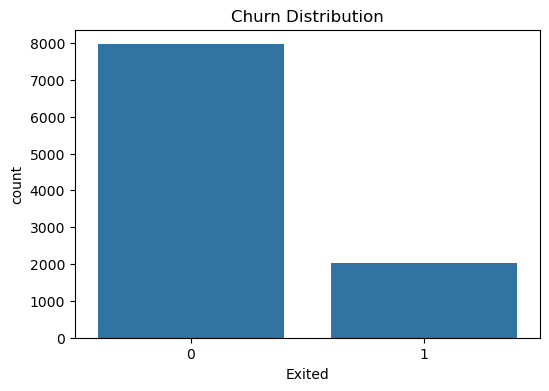

In [6]:

# Churn Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

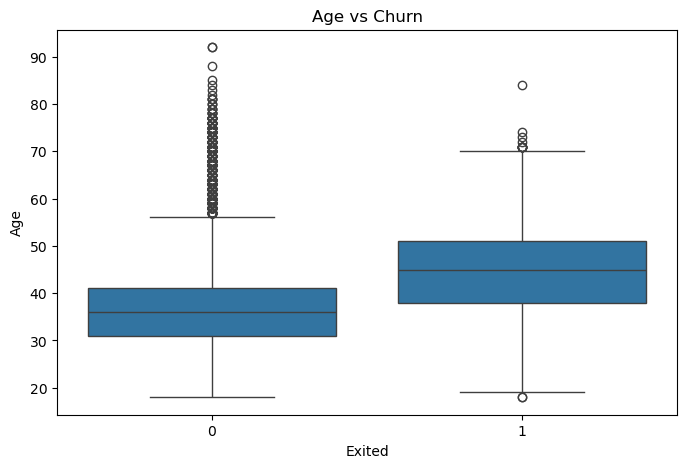

In [7]:
# Age vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

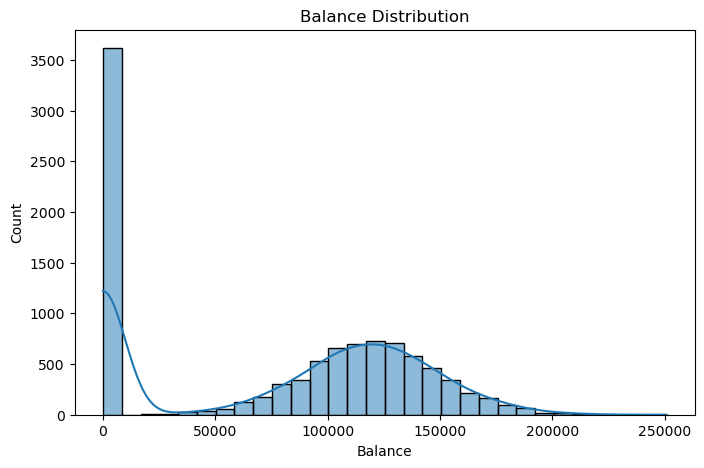

In [8]:

# Balance Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Balance"], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

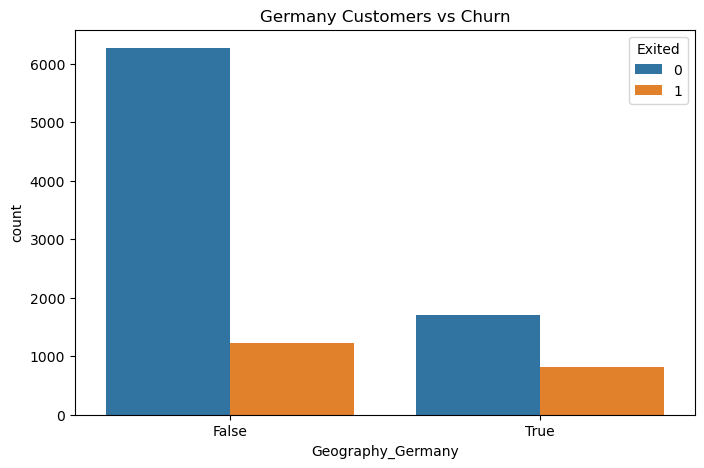

In [9]:

# Geography vs Churn

plt.figure(figsize=(8,5))
sns.countplot(x="Geography_Germany", hue="Exited", data=df)
plt.title("Germany Customers vs Churn")
plt.show()

# Model Training and Testing

In [10]:

# Split Features and Target

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:

# Train Random Forest Classifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation Metrics

In [12]:

# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8693333333333333


In [13]:

# Confusion Matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[2330   86]
 [ 306  278]]


In [14]:

#Classification Report

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2416
           1       0.76      0.48      0.59       584

    accuracy                           0.87      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.86      0.87      0.86      3000



# Feature Importance Analysis

In [15]:

# Extract feature importance

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

Age                  0.239987
EstimatedSalary      0.145423
Balance              0.143304
CreditScore          0.140535
NumOfProducts        0.127562
Tenure               0.082386
IsActiveMember       0.041465
Geography_Germany    0.025718
Gender               0.019523
HasCrCard            0.019232
dtype: float64

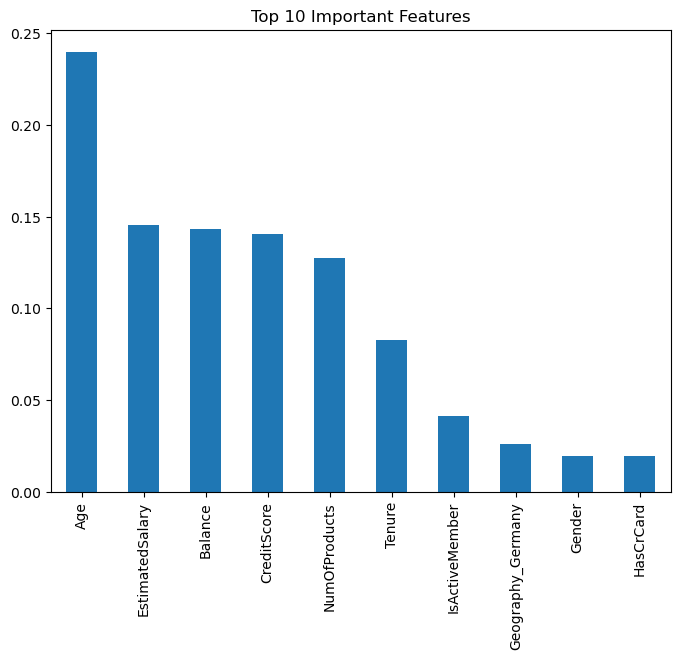

In [16]:

# Visualizing Feature Importance

plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

Conclusion – Key Insights
# Data Insights

Churn rate is around 20%.

Older customers are more likely to churn.

Customers in Germany show higher churn probability.

Active members churn less.

    
# Model Insights

Random Forest performs well for churn prediction.

Age, Balance, and Geography are strong predictors.

Feature importance helps understand customer behavior.
    

# Business Impact

Banks can:

Identify high-risk customers early

Offer retention incentives

Improve customer satisfaction

Reduce revenue loss